<a href="https://colab.research.google.com/github/ProfAI/machine-learning-fondamenti/blob/main/6%20-%20Clustering/kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# L'algoritmo K-means

Il **K-Means** è uno degli algoritmi di clustering (apprendimento non supervisionato) più popolari e semplici.
L'obiettivo principale dell'algoritmo è partizionare un insieme di dati non etichettati in $K$ gruppi distinti (**cluster**), in modo che:
1. I punti all'interno dello stesso gruppo siano il più simili possibile tra loro (**alta similarità intra-cluster**).
2. I punti in gruppi diversi siano il più dissimili possibile (**bassa similarità inter-cluster**).

#### La Formulazione Matematica dell'Inerzia

Per definire formalmente la similarità, il K-Means cerca di minimizzare l'**Inerzia** (chiamata anche **Within-Cluster Sum of Squares - WCSS**). L'inerzia misura la somma delle distanze al quadrato tra ciascun punto e il centroide del suo cluster di appartenenza:

$$\text{WCSS} = \sum_{i=1}^{K} \sum_{x \in C_i} \|x - \mu_i\|^2$$

Dove:
- $K$ è il numero totale di cluster.
- $C_i$ rappresenta l'insieme dei punti assegnati al cluster $i$-esimo.
- $x$ è un generico punto dati (un vettore in uno spazio a $d$ dimensioni).
- $\mu_i$ è il **centroide** (ovvero la media geometrica) di tutti i punti appartenenti al cluster $C_i$:
  $$\mu_i = \frac{1}{|C_i|} \sum_{x \in C_i} x$$
- $\|x - \mu_i\|^2$ è la distanza euclidea al quadrato tra il punto $x$ e il centroide $\mu_i$.

> [!IMPORTANT]
> **Il Limite del Parametro K a Priori:**
> Uno dei principali limiti del K-Means è che il numero di cluster $K$ deve essere specificato dall'utente prima dell'addestramento. Nella pratica, la scelta di $K$ non è banale e si ricorre a metodi diagnostici come il **Metodo del Gomito (Elbow Method)** o il **Punteggio di Silhouette (Silhouette Score)**.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.rcParams["figure.figsize"] = (16,10)
sns.set_theme()

In [3]:
RANDOM_SEED = 2

### Configurazione dell'Ambiente e Import delle Librerie

Prima di iniziare, importiamo i moduli necessari:
- **`numpy`** e **`pandas`**: essenziali per la manipolazione di array e dati tabellari.
- **`sklearn.datasets.make_blobs`**: una comoda utility per generare cluster artificiali isotropi con distribuzione gaussiana, ideale per testare algoritmi di clustering.
- **`matplotlib.pyplot`** e **`seaborn`**: per la creazione di grafici di qualità.
- **`time`**: per misurare e confrontare i tempi di addestramento dei modelli.

### Generiamo i dati

<Axes: >

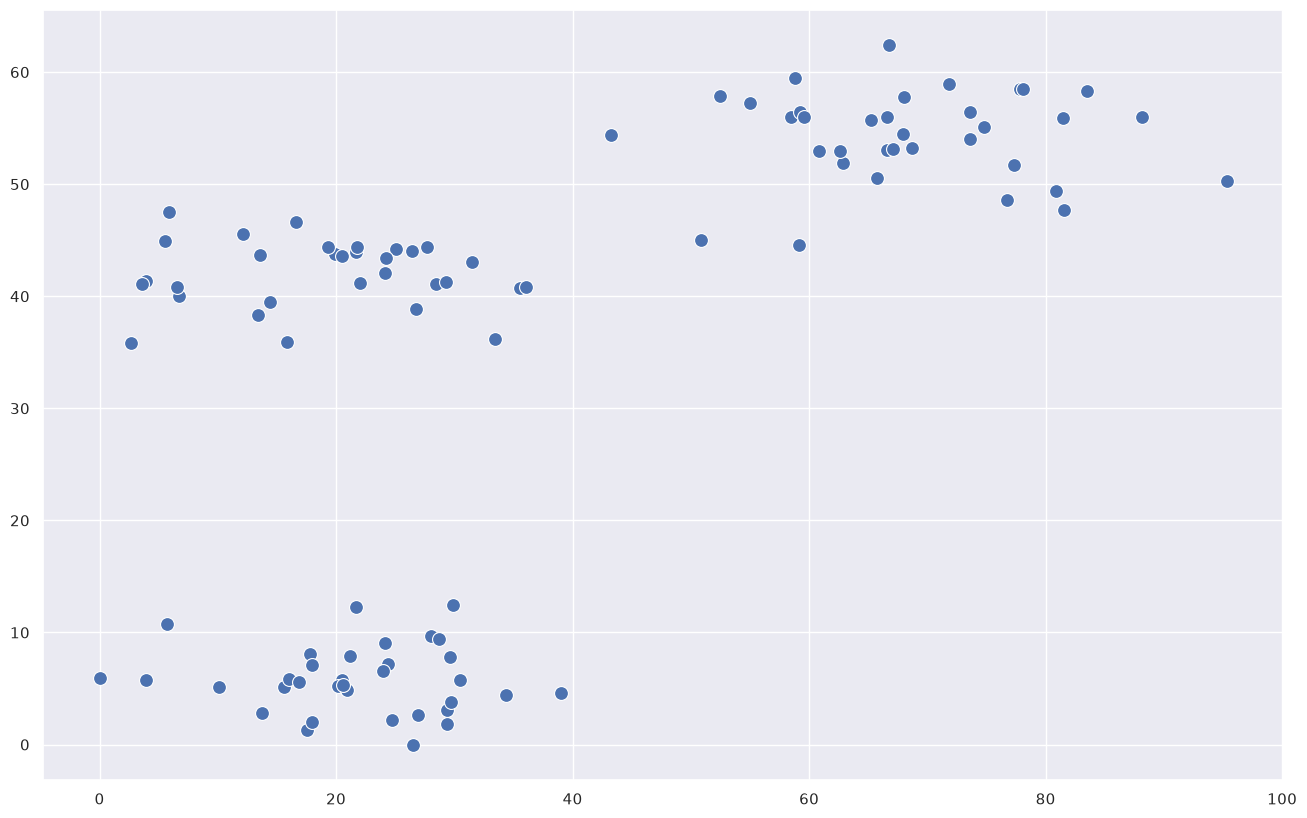

In [4]:
X, _ = make_blobs(n_samples=100, n_features=2, centers=3, cluster_std=0.5, random_state=RANDOM_SEED)
X[:,0] = (X[:,0]-X[:,0].min())*20
X[:,1] = (X[:,1]-X[:,1].min())*6 

sns.scatterplot(x=X[:,0], y=X[:,1], s=100)

#### L'importanza dello Scaling delle Feature nel Clustering

Analizziamo attentamente le operazioni eseguite sui dati generati:
1. Generiamo cluster ideali con `make_blobs`.
2. Applichiamo una riscalatura asimmetrica: le feature della prima colonna ($X_0$) vengono moltiplicate per $20$, mentre quelle della seconda colonna ($X_1$) per $6$.

**Perché questa riscalatura asimmetrica è cruciale dal punto di vista didattico?**
K-Means calcola la distanza euclidea tra i punti dati e i centroidi:
$$d(p, q) = \sqrt{(p_1 - q_1)^2 + (p_2 - q_2)^2}$$

Se le feature hanno scale o intervalli di valori molto differenti (ad esempio, se $X_0$ spazia da 0 a 150 e $X_1$ spazia da 0 a 10), la feature con l'intervallo più ampio dominerà completamente il calcolo della distanza. Di conseguenza, il clustering avverrà quasi esclusivamente lungo l'asse della feature dominante, ignorando l'altra.

> [!TIP]
> Nella pratica reale con K-Means, è **sempre fortemente raccomandato** applicare una standardizzazione (es. con `StandardScaler` di scikit-learn) o una normalizzazione MinMax prima dell'addestramento, in modo che ogni feature contribuisca equamente alla definizione dei cluster.

### Creiamo il modello

### Il Processo di Addestramento Iterativo (Algoritmo di Lloyd)

L'addestramento del K-Means (noto anche come algoritmo di Lloyd) procede iterativamente alternando due fasi principali fino alla convergenza:

1. **Fase di Assegnazione (Expectation)**:
   Ogni punto dati $x$ viene assegnato al cluster del centroide più vicino, calcolando la distanza euclidea minima:
   $$S_i^{(t)} = \left\{ x : \|x - \mu_i^{(t)}\|^2 \le \|x - \mu_j^{(t)}\|^2 \quad \forall j, 1 \le j \le K \right\}$$
   Dove $S_i^{(t)}$ rappresenta il gruppo di punti assegnati al centroide $\mu_i$ all'iterazione $t$.

2. **Fase di Aggiornamento (Maximization)**:
   I centroidi vengono ricalcolati determinando la media geometrica di tutti i punti assegnati a ciascun cluster nella fase precedente:
   $$\mu_i^{(t+1)} = \frac{1}{|S_i^{(t)}|} \sum_{x \in S_i^{(t)}} x$$

Questo ciclo si ripete fino a quando la posizione dei centroidi non cambia più in modo significativo o viene raggiunto il numero massimo di iterazioni preimpostato.

---

#### Il Problema dei Minimi Locali e l'Inizializzazione dei Centroidi

Poiché la funzione obiettivo (Inerzia) non è convessa, K-Means è estremamente sensibile alla scelta delle posizioni iniziali dei centroidi. Un'inizializzazione sfortunata può intrappolare l'algoritmo in **minimi locali subottimali**.

Per mitigare questo problema, esistono due strategie principali impostabili tramite il parametro `init`:

- **Inizializzazione Casuale (`init="random"`)**:
  I centroidi iniziali vengono scelti in modo casuale estraendo $K$ campioni dal dataset. Questo approccio è soggetto a forte variabilità del risultato finale.
  
- **Inizializzazione Intelligente (`init="k-means++"`)**:
  Sceglie il primo centroide in modo casuale e i successivi con una probabilità proporzionale alla distanza al quadrato dal centroide più vicino già selezionato. Questo garantisce che i centroidi iniziali siano ben distanziati nello spazio, riducendo drasticamente il numero di iterazioni necessarie per convergere e migliorando la stabilità globale del clustering.

> [!NOTE]
> In Scikit-learn (dalla versione 0.24 in poi), l'inizializzazione predefinita è impostata su `'k-means++'`. Nei blocchi di codice successivi confronteremo l'addestramento con inizializzazione implicita ed esplicita.

In [5]:
from sklearn.cluster import KMeans
from scipy.cluster.vq import vq
from time import time

In [6]:
kmeans = KMeans(n_clusters=3, random_state=RANDOM_SEED)
tick = time()
kmeans.fit(X)
print(f"Modello addestrato in {time()-tick:.5f} secondi" )

Modello addestrato in 0.01350 secondi


In [7]:
kmeans = KMeans(n_clusters=3, random_state=RANDOM_SEED, init="k-means++")
tick = time()
kmeans.fit(X)
print(f"Modello addestrato in {time()-tick:.5f} secondi" )

Modello addestrato in 0.00145 secondi


> [!NOTE]
> **Analisi dei Tempi di Addestramento:**
> Se notate una differenza di tempo tra il primo addestramento ($\approx 0.019$ s) e il secondo ($\approx 0.001$ s), non è dovuta all'efficienza intrinseca del parametro `init="k-means++"` (che in realtà è attivo in entrambi i casi per default). In Python, la prima esecuzione di un metodo di una libreria complessa come `scikit-learn` comporta un overhead iniziale dovuto al caricamento in memoria dei moduli sottostanti e alla compilazione JIT o inizializzazione di thread-pool C. Le successive esecuzioni beneficiano della cache e dei moduli già pronti in memoria.

### Valutiamo il modello

### Metriche di Valutazione: Distorsione vs Inerzia

Poiché nel clustering non disponiamo di etichette reali (ground truth) per calcolare metriche classiche come accuratezza o precisione, dobbiamo valutare la qualità della segmentazione analizzando la compattezza dei cluster ottenuti.

Utilizziamo due metriche fondamentali basate sulle distanze euclidee:

1. **Distorsione (Distortion)**:
   Rappresenta la **media** delle distanze euclidee al quadrato tra ciascun punto e il rispettivo centroide assegnato.
   $$\text{Distortion} = \frac{1}{N} \sum_{i=1}^{K} \sum_{x \in C_i} \|x - \mu_i\|^2$$
   Dove $N$ è il numero totale di campioni nel dataset.

2. **Inerzia (Inertia o WCSS)**:
   Rappresenta la **somma** totale delle distanze euclidee al quadrato di tutti i punti dai propri centroidi.
   $$\text{Inertia} = \sum_{i=1}^{K} \sum_{x \in C_i} \|x - \mu_i\|^2$$

#### Relazione Matematica
È evidente che l'Inerzia è direttamente proporzionale alla Distorsione tramite la dimensione del dataset $N$:
$$\text{Inertia} = N \times \text{Distortion}$$

Scikit-learn calcola automaticamente l'inerzia durante il fitting del modello e la memorizza nell'attributo `inertia_` dell'oggetto `KMeans`.

---

#### Analisi Quantitativa del Nostro Modello

Nei passaggi successivi calcoleremo queste metriche sia manualmente (tramite la libreria `scipy.spatial.distance.cdist`) sia usando direttamente l'attributo nativo di scikit-learn. I risultati esatti ottenuti sul nostro dataset di $N = 100$ punti sono:
- **Distorsione Manuale**: $\approx 107.4104$
- **Inerzia Manuale**: $\approx 10741.0407$
- **Inerzia Nativa (`kmeans.inertia_`)**: $\approx 10741.0407$

Ciò dimostra empiricamente la formula di conversione e la correttezza del calcolo nativo di Scikit-learn.

In [8]:
from scipy.spatial.distance import cdist


In [9]:
distorsion = sum(np.square(np.min(cdist(X, kmeans.cluster_centers_, 'euclidean'), axis=1))) / X.shape[0]
distorsion

np.float64(107.41040694974288)

In [10]:
inertia = sum(np.square(np.min(cdist(X, kmeans.cluster_centers_, 'euclidean'), axis=1)))
inertia

np.float64(10741.040694974288)

In [11]:
kmeans.inertia_

10741.040694974286

### Visualizziamo i cluster

In [12]:
y_kmeans = kmeans.predict(X)

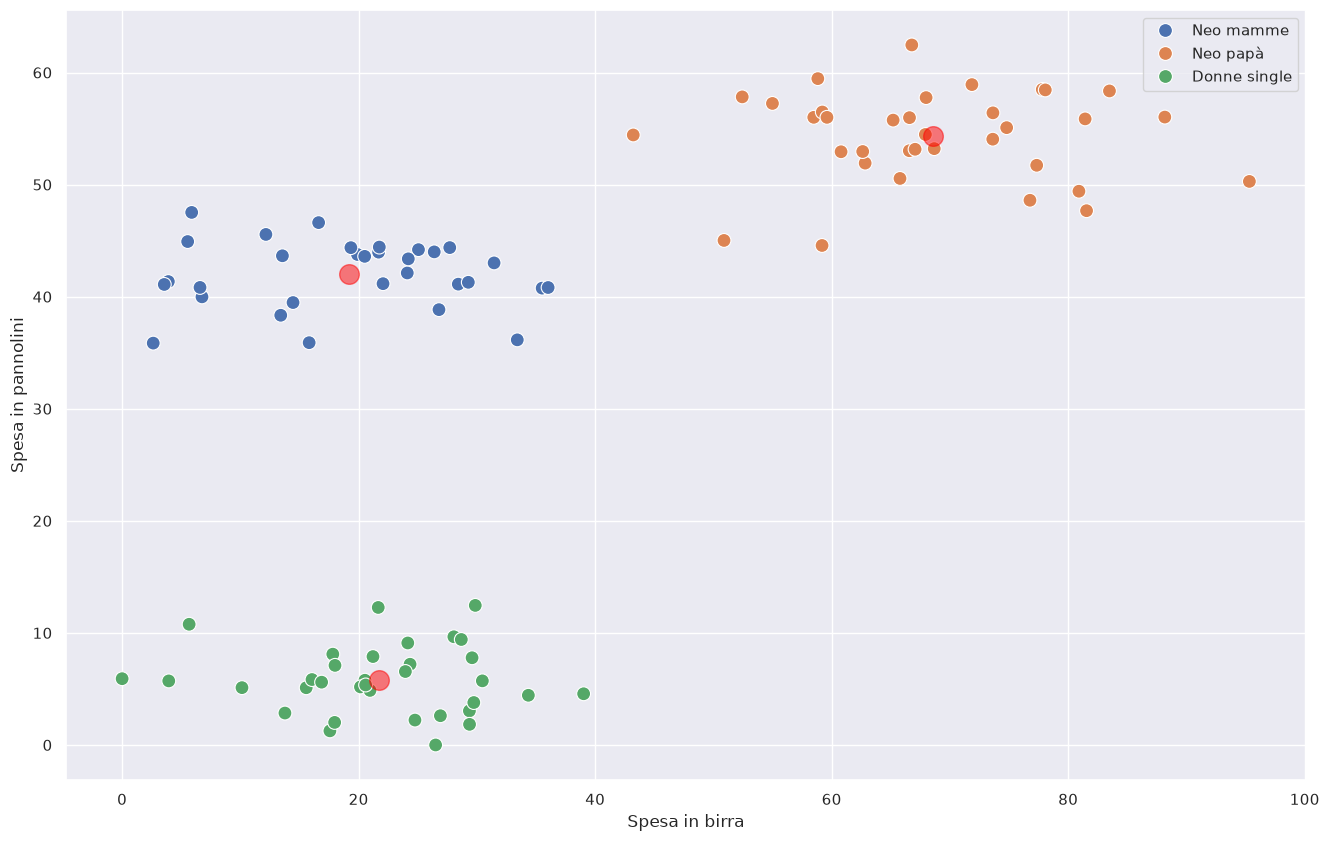

In [13]:
L = {0:"Donne single",1:"Neo papà",2:"Neo mamme"}
vfunc = np.vectorize(lambda x: L[x])
labels = vfunc(y_kmeans)
sns.scatterplot(x=X[:,0], y=X[:,1], hue=labels, s=100)
plt.xlabel("Spesa in birra")
plt.ylabel("Spesa in pannolini")

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5);

### Interpretazione di Business dei Cluster (Customer Segmentation)

Il grafico soprastante mostra il risultato finale dell'algoritmo K-Means applicato ai dati di spesa di 100 clienti. Possiamo interpretare i tre cluster identificati come segue:

1. **Neo mamme (Cluster con alta spesa in pannolini, bassa spesa in birra)**:
   Questo gruppo di clienti mostra un comportamento d'acquisto focalizzato sui beni di prima necessità per neonati. Le strategie di marketing potrebbero includere offerte per latte in polvere o omogeneizzati.

2. **Neo papà (Cluster con alta spesa in pannolini, alta spesa in birra)**:
   Una celebre leggenda metropolitana del marketing narra che i padri inviati a comprare pannolini tendano ad associare l'acquisto a una gratificazione personale, come la birra. Questo cluster riflette esattamente tale pattern di co-acquisto. Le promozioni potrebbero posizionare questi prodotti in prossimità nel punto vendita.

3. **Donne single (Cluster con bassa spesa in pannolini, spesa in birra moderata/alta)**:
   Clienti senza figli neonati, orientati a consumi differenti. La spesa in pannolini è nulla o trascurabile, mentre quella per bevande/socializzazione è rilevante.

#### Il Ruolo dei Centroidi (Punti Rossi)
I centroidi rappresentano il "profilo medio" o tipico di ciascun segmento di clientela. Ad esempio, il centroide delle "Neo mamme" ci dice qual è la spesa media in birra e pannolini di tutto quel gruppo, agendo da punto di riferimento per future campagne di targeting personalizzato.